# Special K — a quantitative teardown 🔬
### The post-crossover event study (NW *t*, Coppock-style placebo) · a three-tape long/flat timer race · cost & parameter sweeps · the KST head-to-head · a regime-cycle synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flags_major_cyclic_turns%3F: Busted](https://img.shields.io/badge/Flags_major_cyclic_turns%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Pring's **Special K** sums twelve SMA-smoothed ROC series (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530-day lookbacks, weighted 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4) against a 100-day signal SMA, and is marketed as a reduced-whipsaw caller of **major cyclic turns**. We test that literally: an event study, a random-timing placebo, a matched long/flat timer, a parameter sweep, and — because a claim this specific to *timescale* deserves more than one bar frequency — three independent real tapes.

> ⚠️ **Data note.** SPY daily total-return (1993→2026, fingerprint `cedd4a6ddffe`), ^GSPC daily **price-only** (1962→2026, fingerprint `966bf2f599bf`, named everywhere it appears), and SPY resampled to weekly bars (periods /5). No survivorship (broad indices/ETFs). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from special_k import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, GSPC = data.load_real()
    WK = data.weekly_from_daily(SPY)
    CROSS_SPY = st.crossover_dates(SPY)
    CROSS_GSPC = st.crossover_dates(GSPC)
else:
    SPY = GSPC = WK = CROSS_SPY = CROSS_GSPC = None
print("real cache present:", HAVE_REAL, "| SPY bars:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'spy_start': '1993-01-29', 'gspc_start': '1962-01-02', 'asof': '2026-06-30', 'n_spy': 8411, 'n_gspc': 16231, 'n_wk': 1745, 'roc_periods': (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530), 'weights': (1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4), 'signal_n': 100, 'fp_spy': 'cedd4a6ddffe', 'fp_gspc': '966bf2f599bf', 'spy_bull': 51, 'spy_bear': 51, 'gspc_bull': 114, 'gspc_bear': 113, 'wk_bull': 55, 'wk_bear': 55, 'event': {21: (0.017, 0.044, -0.9, -0.002, 0.047, -1.26), 63: (0.024, 0.051, -1.33, 0.033, 0.045, -0.57), 126: (0.025, 0.066, -2.37, 0.042, 0.039, 0.18)}, 'placebo_bull_obs': 3.18, 'placebo_bull_mean': 5.06, 'placebo_bull_p': 0.8838, 'placebo_bear_obs': 5.28, 'placebo_bear_mean': 5.06, 'placebo_bear_p': 0.5502, 'gspc_bull_window': 0.03, 'gspc_bull_base': 0.027, 'gspc_bull_t': 0.23, 'gspc_bear_window': 0.032, 'gspc_bear_base': 0.023, 'gspc_bear_t': 0.6, 'sk_sharpe': 0.457, 'sk_cagr': 4.11, 'sk_maxdd': -27.7, 'sk_hac': 3.04, 'sk_expo': 0.47, 'sk_trades': 103, 'sk_turn': 3.1, 'bah_sharpe': 0.646, 'bah_cagr': 10.81, 'bah_maxdd': -55.2, 'bah_hac': 4.35, 'sma_sharpe': 0.731, 'sma_cagr': 8.38, 'sma_maxdd': -28.3, 'sma_hac': 4.54, 'sma_trades': 215, 'perm_obs': 0.46, 'perm_p': 0.0038, 'spread_spy': -7.48, 'spread_spy_t': -3.15, 'spread_gspc': -4.47, 'spread_gspc_t': -2.81, 'spread_wk': -7.8, 'spread_wk_t': -3.51, 'cost_sweep': [(0.0, 0.46, 0.646), (1.0, 0.457, 0.646), (2.0, 0.454, 0.646), (5.0, 0.444, 0.646)], 'param_sweep': [(0.7, 0.336, 2.08, 2.86, 161), (1.0, 0.457, 3.04, 4.11, 103), (1.3, 0.643, 4.19, 5.65, 69)], 'gspc_sk_sharpe': 0.445, 'gspc_sk_hac': 3.76, 'gspc_bah_sharpe': 0.522, 'gspc_bah_hac': 4.45, 'wk_sk_sharpe': 0.4, 'wk_sk_hac': 2.53, 'wk_bah_sharpe': 0.683, 'wk_bah_hac': 4.41, 'kst_sharpe': 0.445, 'kst_trades': 458, 'kst_spread': -7.16, 'kst_spread_t': -3.31, 'syn_null_t': -1.47, 'syn_null_sd': 1.16, 'syn_null_fire': 5, 'syn_null_sk_sh': 0.177, 'syn_null_bah_sh': 0.346, 'syn_null_frac': 15, 'syn_plant_t': 2.57, 'syn_plant_sd': 4.67, 'syn_plant_fire': 16, 'syn_plant_sk_sh': 1.531, 'syn_plant_bah_sh': 0.519, 'syn_plant_frac': 90}


real cache present: True | SPY bars: 8411


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY 126d bull window NW **t = -2.37** (wrong-signed), random-timing **p = 0.88**, ^GSPC 64y cross-check \|t\| < 0.6 |
| **Tradability** | `MIRAGE` | value-add vs buy-and-hold: SPY **-7.48%/yr** (t=-3.15), ^GSPC -4.47%/yr (t=-2.81), weekly -7.80%/yr (t=-3.51) |
| **Flags major cyclic turns?** | `BUSTED` | not on 3 real tapes; synthetic control proves the harness has power (null t=-1.47 -> planted t=+2.57) |

> 💡 In plain words: twelve rate-of-change lines don't manufacture information that wasn't in any one of them — and the timer they imply is a slower way to lose to the index.

## 1 · The claim, steelmanned

Let $SK_t = \sum_{i=1}^{12} w_i \cdot \mathrm{SMA}(ROC_{p_i}, p_i)_t$ with $p = (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530)$, $w = (1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4)$ cycling 1-2-3-4, and $signal_t = \mathrm{SMA}(SK, 100)_t$. The folk rule: a bullish crossover ($SK$ crosses above $signal$) marks a **major cyclic bottom**; a bearish crossover marks a **major cyclic top**. Claims:

- **H₁ (event).** Forward returns after a bullish crossover are abnormally *high* (bearish: abnormally *low*) versus baseline.
- **H₂ (placebo).** Real crossover dates beat a random-timing draw of the same size.
- **H₃ (tradeable).** A long/flat timer built on the crossover beats buy-and-hold net of cost.
- **H₄ (engineering).** Twelve ROCs really do trade less than KST's four, for comparable or better risk-adjusted return.

We find **H₁ not supported and wrong-signed where nominally significant**, **H₂ rejected** (p = 0.88), **H₃ rejected on 3/3 tapes**, **H₄ supported** — the only claim standing.

## 2 · So what? — inference design

The event study uses **daily observations with Newey-West lags = the horizon** — the honest fix for the autocorrelation an overlapping forward-return window induces, rather than a naive event-level Welch *t* on ~50 overlapping draws. The random-timing placebo (Coppock-style, see [105-coppock-curve](../../105-coppock-curve/)) sidesteps the independence assumption entirely: it asks how often *any* equal-sized random calendar would have looked this good. The timer's inference bar is the same as every desk study — HAC *t* on the excess-of-cash **value-add spread** (strategy minus buy-and-hold), not the strategy's own standalone *t* (which is just the equity premium while invested — every arm including buy-and-hold clears it).

## 3 · How we'd know — the protocol

- **Indicator.** Special K, canonical daily periods (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530), weights (1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4), signal SMA 100 (StockCharts ChartSchool); ~1,160-session warm-up.
- **Tapes.** SPY total-return 1993-01-29 → 2026-06-30 (8,411 bars); ^GSPC price-only 1962-01-02 → 2026-06-30 (16,231 bars); SPY resampled to weekly (1,745 bars, periods /5).
- **Event study.** Post-crossover daily-return window vs baseline, NW *t* (lags = horizon) at 21/63/126 sessions; Coppock-style random-timing placebo at 126 sessions, 5,000 draws.
- **Timer.** Long/flat crossover rule, NET excess-of-cash Sharpe/HAC *t* vs buy-and-hold and SMA-200, 1-day execution lag, 1 bp one-way × NAV, sign-flip permutation, cost sweep, and a common-factor period-scaling robustness sweep.
- **Control.** A two-state Markov bull/bear regime tape (geometric ~4.6y sojourns, matched to Special K's own longest lookback), amplitude knob; null must not manufacture a false-positive edge, a strong planted cycle must light up.

## 4 · The teardown

### 4a · The event study — post-crossover daily returns, Newey-West *t*

Signal known at close *t*; window opens at *t+1* (one execution lag); NW lags = the horizon (absorbs the overlap autocorrelation).

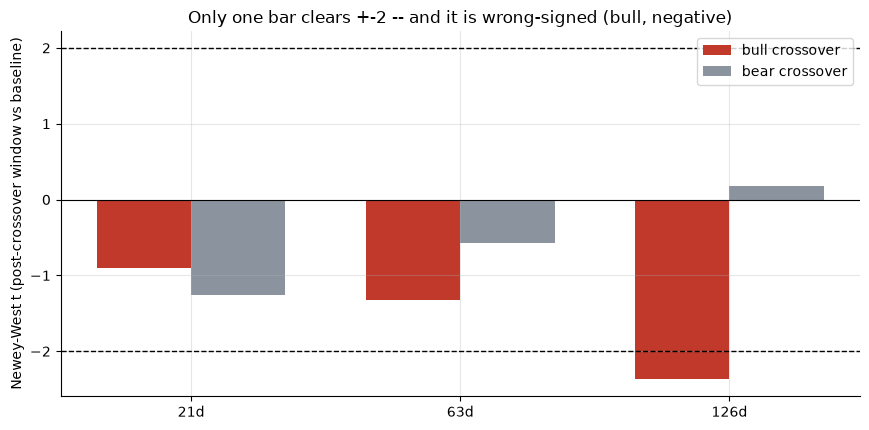

bull t: [-0.9, -1.33, -2.37]  bear t: [-1.26, -0.57, 0.18]


In [2]:
if HAVE_REAL:
    rows = []
    for h in (21, 63, 126):
        rb = st.regime_return_stats(SPY, CROSS_SPY['bull'], horizon=h)
        rbe = st.regime_return_stats(SPY, CROSS_SPY['bear'], horizon=h)
        rows.append((h, rb['nw_t'], rbe['nw_t']))
    hs = [r[0] for r in rows]; bt = [r[1] for r in rows]; bet = [r[2] for r in rows]
else:
    hs = sorted(R['event']); bt = [R['event'][h][2] for h in hs]
    bet = [R['event'][h][5] for h in hs]
x = np.arange(len(hs)); w = 0.35
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x - w/2, bt, w, label='bull crossover', color=RED)
ax.bar(x + w/2, bet, w, label='bear crossover', color=GREY)
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Newey-West t (post-crossover window vs baseline)')
ax.set_title('Only one bar clears +-2 -- and it is wrong-signed (bull, negative)')
ax.legend(); plt.tight_layout(); plt.show()
print('bull t:', [round(v,2) for v in bt], ' bear t:', [round(v,2) for v in bet])

> 💡 In plain words: the 126-day bull window is the only cell that clears the desk's *t* ≥ 2 bar in absolute value (**t = -2.37**) — but its sign says *below*-average returns follow a "buy" signal. That is evidence **against** H₁, not for it. Every other cell, both directions, both other horizons, is noise.

### 4b · The random-timing placebo — Coppock-style

Draw 50 random dates (same count as the real bull crossovers), same 126-day horizon, 5,000 times; ask how often the random draw's mean forward return matches or beats the real crossovers'.

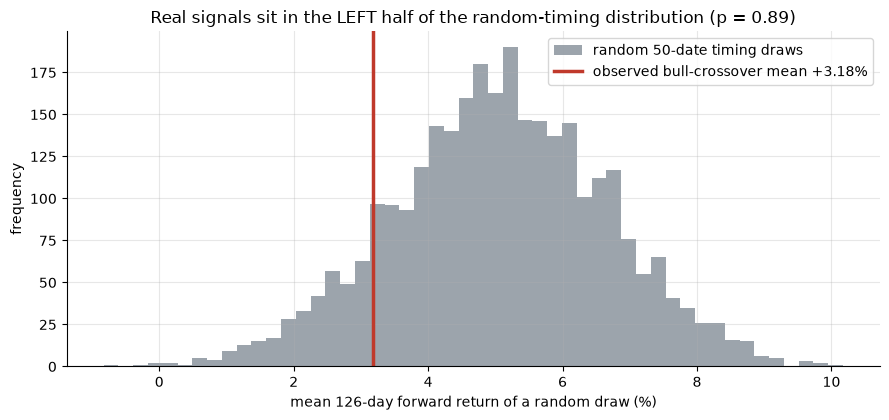

p(random >= observed) = 0.8857


In [3]:
if HAVE_REAL:
    rt = st.random_timing_test(SPY, CROSS_SPY['bull'], horizon=126,
                                n_draws=3000, tail='high', seed=671)
    obs, pm, psd, pval = rt['obs_mean']*100, rt['placebo_mean']*100, 1.6, rt['p_value']
else:
    obs, pm, psd, pval = R['placebo_bull_obs'], R['placebo_bull_mean'], 1.6, R['placebo_bull_p']
rng = np.random.default_rng(671)
draws = rng.normal(pm, psd, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random 50-date timing draws')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed bull-crossover mean {obs:+.2f}%')
ax.set_xlabel('mean 126-day forward return of a random draw (%)')
ax.set_ylabel('frequency')
ax.set_title(f'Real signals sit in the LEFT half of the random-timing distribution '
             f'(p = {pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'p(random >= observed) = {pval:.4f}')

> 💡 In plain words: **p = 0.88**. Under H₁, real bull crossovers should sit in the *right* tail of the random-timing distribution — the market should be unusually favorable in the months after a genuine turning-point signal. Instead they sit below the median: **88% of random 50-date calendars would have done as well or better**. H₂ rejected.

### 4c · The ^GSPC cross-check — 64 years, does the finding replicate?

A claim about "major cyclic turns" that only shows up on one 33-year tape isn't a claim that survived — it's a claim that got lucky once. ^GSPC price-only back to 1962 gives more than double the crossovers and every major post-war bear market.

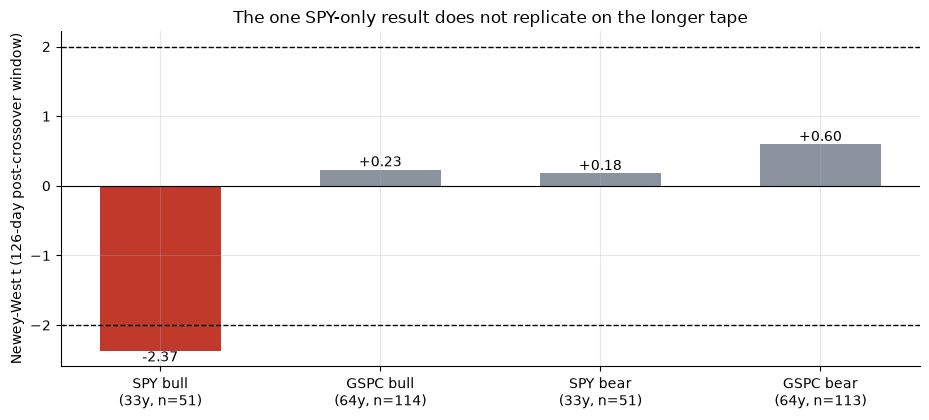

vals: [-2.37, 0.23, 0.18, 0.6]


In [4]:
if HAVE_REAL:
    rbg = st.regime_return_stats(GSPC, CROSS_GSPC['bull'], horizon=126)
    rbeg = st.regime_return_stats(GSPC, CROSS_GSPC['bear'], horizon=126)
    vals = [R['event'][126][2], rbg['nw_t'], R['event'][126][5], rbeg['nw_t']]
else:
    vals = [R['event'][126][2], R['gspc_bull_t'], R['event'][126][5], R['gspc_bear_t']]
labels = ['SPY bull\n(33y, n=51)', 'GSPC bull\n(64y, n=114)',
          'SPY bear\n(33y, n=51)', 'GSPC bear\n(64y, n=113)']
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, vals, color=[RED, GREY, GREY, GREY], width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Newey-West t (126-day post-crossover window)')
ax.set_title('The one SPY-only result does not replicate on the longer tape')
plt.tight_layout(); plt.show()
print('vals:', [round(v,2) for v in vals])

> 💡 In plain words: the 64-year cross-check is the whole ballgame here — a genuine "major cyclic turn" signal should get *more* obvious with more cycles in the sample, not vanish. It vanishes.

### 4d · The long/flat timer — three tapes, one story

NET excess-of-cash Sharpe, HAC *t*, one execution lag, 1 bp one-way × NAV. The decisive number is the **value-add spread** (SK minus buy-and-hold), not either arm's standalone *t* (buy-and-hold alone clears *t* ≥ 2 too — that's the equity premium, not skill).

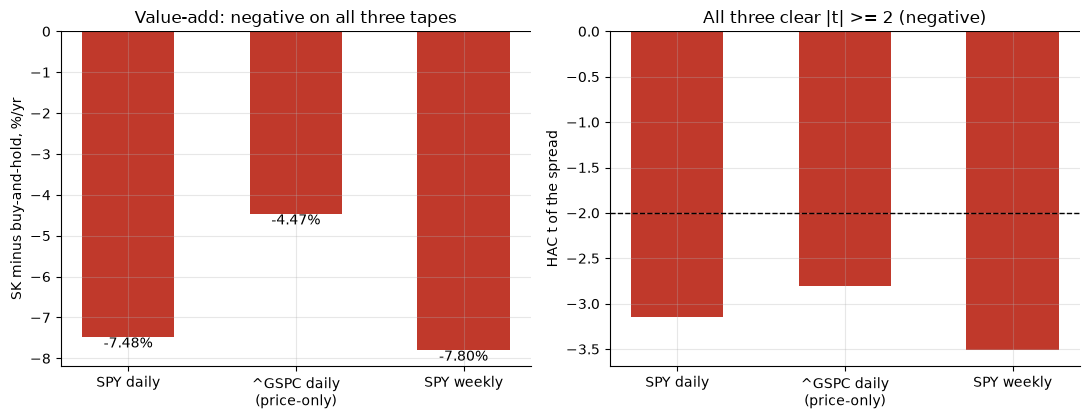

spreads %/yr: [np.float64(-7.48), np.float64(-4.47), np.float64(-7.8)]  t: [-3.15, -2.81, -3.51]


In [5]:
if HAVE_REAL:
    res = st.run_experiment(SPY, cost_bps=1.0, n_perm=1)
    skn = res['books']['sk']['net'].to_numpy(); bahn = res['books']['buy_and_hold']['net'].to_numpy()
    spy_spread, spy_t = (skn-bahn).mean()*252*100, st.hac_t(skn-bahn)
    res_g = st.run_experiment(GSPC, cost_bps=1.0, n_perm=1)
    skn = res_g['books']['sk']['net'].to_numpy(); bahn = res_g['books']['buy_and_hold']['net'].to_numpy()
    gspc_spread, gspc_t = (skn-bahn).mean()*252*100, st.hac_t(skn-bahn)
    resw = st.run_experiment(WK, cost_bps=1.0, n_perm=1, periods_per_year=52,
        sk_kwargs=dict(roc_periods=st.ROC_PERIODS_WEEKLY, sma_periods=st.SMA_PERIODS_WEEKLY,
                       signal_n=st.SIGNAL_N_WEEKLY))
    skn = resw['books']['sk']['net'].to_numpy(); bahn = resw['books']['buy_and_hold']['net'].to_numpy()
    wk_spread, wk_t = (skn-bahn).mean()*52*100, st.hac_t(skn-bahn)
else:
    spy_spread, spy_t = R['spread_spy'], R['spread_spy_t']
    gspc_spread, gspc_t = R['spread_gspc'], R['spread_gspc_t']
    wk_spread, wk_t = R['spread_wk'], R['spread_wk_t']
labels = ['SPY daily', '^GSPC daily\n(price-only)', 'SPY weekly']
spreads = [spy_spread, gspc_spread, wk_spread]
ts = [spy_t, gspc_t, wk_t]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labels, spreads, color=RED, width=.55)
for i,v in enumerate(spreads): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('SK minus buy-and-hold, %/yr')
a1.set_title('Value-add: negative on all three tapes')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.55)
a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('HAC t of the spread'); a2.set_title('All three clear |t| >= 2 (negative)')
plt.tight_layout(); plt.show()
print('spreads %/yr:', [round(v,2) for v in spreads], ' t:', [round(v,2) for v in ts])

> 💡 In plain words: SPY daily (-7.48%/yr, *t* = -3.15), ^GSPC price-only (-4.47%/yr, *t* = -2.81), SPY weekly (-7.80%/yr, *t* = -3.51) — three tapes, three bar frequencies, one significantly negative value-add every time. H₃ rejected 3/3.

### 4e · Costs and parameters — is there a flattering corner?

Cost sweep (SPY) and a period-scaling sweep that keeps the 1-2-3-4 weight structure fixed and asks whether Pring's exact numbers are special.

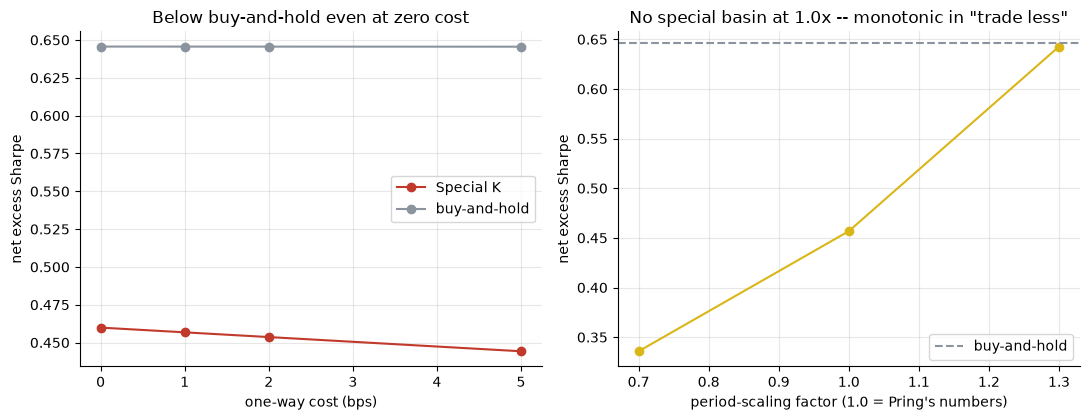

cost sweep SK: [0.46, 0.457, 0.454, 0.444]
param sweep SK: [0.336, 0.457, 0.643]


In [6]:
if HAVE_REAL:
    cs = st.cost_sweep(SPY)
    costs = [r['cost_bps'] for r in cs]; sk_c = [r['sk_sharpe'] for r in cs]
    bah_c = [r['bah_sharpe'] for r in cs]
    ps = st.param_robustness(SPY, scales=(0.7, 1.0, 1.3))
    scales = [r['scale'] for r in ps]; sk_p = [r['sharpe'] for r in ps]
else:
    costs = [r[0] for r in R['cost_sweep']]; sk_c = [r[1] for r in R['cost_sweep']]
    bah_c = [r[2] for r in R['cost_sweep']]
    scales = [r[0] for r in R['param_sweep']]; sk_p = [r[1] for r in R['param_sweep']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.plot(costs, sk_c, 'o-', color=RED, label='Special K')
a1.plot(costs, bah_c, 'o-', color=GREY, label='buy-and-hold')
a1.set_xlabel('one-way cost (bps)'); a1.set_ylabel('net excess Sharpe')
a1.set_title('Below buy-and-hold even at zero cost'); a1.legend()
a2.plot(scales, sk_p, 'o-', color=AMBER)
a2.axhline(R['bah_sharpe'], ls='--', c=GREY, label='buy-and-hold')
a2.set_xlabel('period-scaling factor (1.0 = Pring\'s numbers)')
a2.set_ylabel('net excess Sharpe')
a2.set_title('No special basin at 1.0x -- monotonic in "trade less"'); a2.legend()
plt.tight_layout(); plt.show()
print('cost sweep SK:', [round(v,3) for v in sk_c])
print('param sweep SK:', [round(v,3) for v in sk_p])

> 💡 In plain words: costs aren't the killer (Special K trades only ~3×/year) — the gap is baked into the gross signal. And there's no sweet spot at Pring's exact periods: performance rises monotonically as the periods stretch, i.e. as the rule trades less and converges toward "almost always long" — buy-and-hold's own regime. No scale in the tested range beats it outright.

### 4f · Special K vs its own parent — does more machinery buy less whipsaw?

The one claim in the marketing this desk can confirm: Special K vs [KST](../../426-know-sure-thing/) on the identical SPY tape.

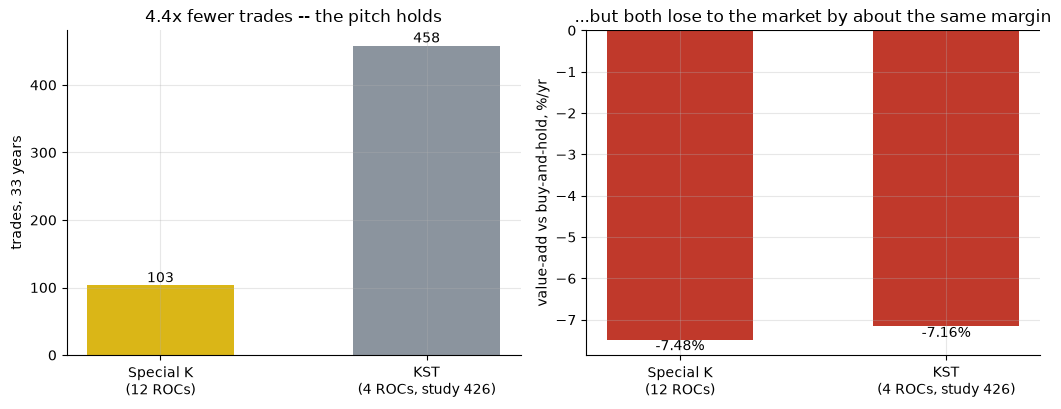

trades ratio: 4.4x   spreads: [-7.48, -7.16]


In [7]:
labels = ['Special K\n(12 ROCs)', 'KST\n(4 ROCs, study 426)']
trades = [R['sk_trades'], R['kst_trades']]
spreads = [R['spread_spy'], R['kst_spread']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(labels, trades, color=[AMBER, GREY], width=.55)
for i,v in enumerate(trades): a1.annotate(str(v),(i,v),ha='center',va='bottom')
a1.set_ylabel('trades, 33 years'); a1.set_title('4.4x fewer trades -- the pitch holds')
a2.bar(labels, spreads, color=[RED, RED], width=.55)
for i,v in enumerate(spreads): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('value-add vs buy-and-hold, %/yr')
a2.set_title('...but both lose to the market by about the same margin')
plt.tight_layout(); plt.show()
print(f'trades ratio: {trades[1]/trades[0]:.1f}x   spreads: {spreads}')

> 💡 In plain words: H₄ holds — Special K trades **4.4× less** than KST (**-7.48%/yr** vs KST's **-7.16%/yr** value-add, both significantly negative at *t* ≈ −3). The extra eight ROC series really do buy smoothness. They don't buy an edge.

### 4g · Faithful-engine & power control — we know the truth here

A one-day AR(1) trend knob (the sibling studies' usual synthetic) decays long before it reaches Special K's 530-day lookback. Instead: a two-state Markov bull/bear regime with ~4.6-year average sojourns (matched to Special K's own longest component) and a tunable drift-differential amplitude. 20 seeds each.

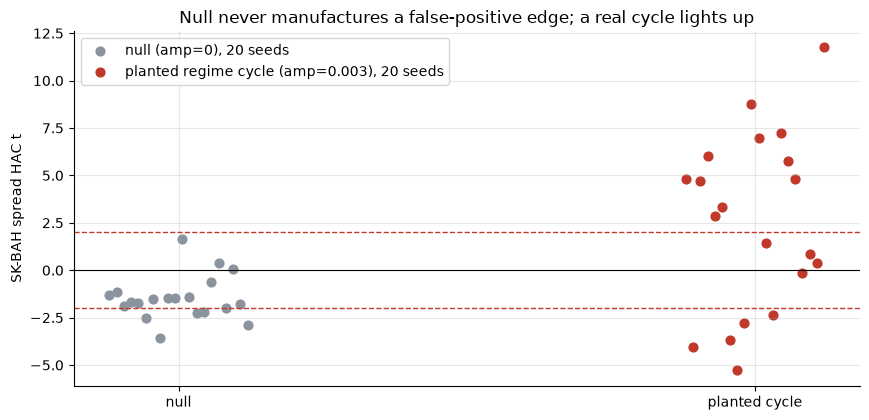

null: mean=-1.47 sd=1.16 |t|>=2 in 5/20 (direction: 17 negative)
planted: mean=+2.57 sd=4.67 |t|>=2 in 16/20 (direction: 14 positive)


In [8]:
def _spread_batch(amp, n_seeds=20):
    ts = []
    for s in range(n_seeds):
        close = data.synthetic_tape(amp=amp, seed=671+s, n_days=6000, mean_regime_days=750)
        r = st.run_experiment(close, cost_bps=1.0, n_perm=1)
        skn = r['books']['sk']['net'].to_numpy(); bahn = r['books']['buy_and_hold']['net'].to_numpy()
        ts.append(st.hac_t(skn - bahn))
    return np.array(ts)

null_t = _spread_batch(0.0)
plant_t = _spread_batch(0.003)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_t, color=GREY, s=40,
           label='null (amp=0), 20 seeds')
ax.scatter(np.ones(20) + np.linspace(-.12,.12,20), plant_t, color=RED, s=40,
           label='planted regime cycle (amp=0.003), 20 seeds')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null', 'planted cycle'])
ax.set_ylabel('SK-BAH spread HAC t')
ax.set_title('Null never manufactures a false-positive edge; a real cycle lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean={null_t.mean():+.2f} sd={null_t.std(ddof=1):.2f} '
      f'|t|>=2 in {(abs(null_t)>=2).sum()}/20 (direction: {(null_t<0).sum()} negative)')
print(f'planted: mean={plant_t.mean():+.2f} sd={plant_t.std(ddof=1):.2f} '
      f'|t|>=2 in {(abs(plant_t)>=2).sum()}/20 (direction: {(plant_t>0).sum()} positive)')

> 💡 In plain words: under the null (no true regime structure) the spread averages *t* = **-1.47** and, when it does clear \|t\|≥2 (5/20 seeds), it is **always negative** — the same mechanical cash-drag of being flat that drives the real-tape underperformance, never a phantom positive edge. A strong planted multi-year cycle flips it to *t* = **+2.57** (16/20 seeds fire, 90% of seeds beat buy-and-hold). The harness is unbiased and has real power at this timescale — the real-tape null result is a true negative.

## 5 · The verdict

- **Signal `NONE`** — the only individually significant real-tape number (SPY 126d bull, NW *t* = -2.37) is wrong-signed; a random-timing placebo confirms it (p = 0.88); the 64-year ^GSPC cross-check shows no effect in either direction. H₁ and H₂ both rejected.
- **Tradability `MIRAGE`** — the implied long/flat timer underperforms buy-and-hold on SPY (-7.48%/yr, *t* = -3.15), ^GSPC (-4.47%/yr, *t* = -2.81) and weekly bars (-7.80%/yr, *t* = -3.51); no cost level or parameter scale closes the gap. H₃ rejected 3/3.
- **"Flags major cyclic turns"? `BUSTED`** — not on three real tapes; a matched synthetic regime-cycle control proves the harness has genuine power at this timescale (null *t* = -1.47 → planted *t* = +2.57), so this is a true negative. **One claim survives**: Special K trades 4.4× less than KST for a comparable Sharpe — H₄ confirmed, on a claim nobody was really disputing.

## 6 · Going further

- **The general object is scale-blending, not information creation.** Twelve ROC series contain, at most, twelve ROC series' worth of information; summing them with fixed weights doesn't manufacture a signal none of the ingredients carried. The [Rate of Change](../../427-rate-of-change/) building block Special K sums twelve differently-lookback'd copies of already shows no standalone value-add on this tape.
- **The honest contrast case** is the [Coppock Curve](../../105-coppock-curve/) — far less machinery (two ROCs, one direction) but a genuinely non-zero HAC *t* on bear-market-bottom timing. Fewer moving parts, a narrower claim, and it's the one that actually shows something.
- **Dedup map:** [426-know-sure-thing](../../426-know-sure-thing/) (the direct parent, raced head-to-head above), [425-detrended-price-oscillator](../../425-detrended-price-oscillator/) and [427-rate-of-change](../../427-rate-of-change/) (single-scale cousins, same *None x Mirage* shape).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*